# SI 699 Mini Project — EDA: Visits to American National Parks

Branch: `Sikandar`. Exploratory analysis of the NPS by-month visitation dataset
(1979–2023) ahead of picking a claim for the mini project write-up.

Source: `US-National-Parks_Use_1979-2023_By-Month.csv`, from the
[Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/)
project (data essay cited there covers collection methods and caveats).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", font_scale=1.0)

# validated categorical palette (see dataviz skill reference/palette.md)
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
CAT_PALETTE = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]


## Load and clean

In [2]:
df = pd.read_csv("../data/US-National-Parks_Use_1979-2023_By-Month.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()
for col in ["ParkName", "UnitCode", "ParkType", "Region", "State"]:
    df[col] = df[col].str.strip()

df["Date"] = pd.to_datetime(dict(year=df.Year, month=df.Month, day=1))
df["ZeroVisits"] = df["RecreationVisits"] == 0

print(df.shape)
df.head()


(33395, 14)


,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry,Date,ZeroVisits
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0,1979-01-01,False
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0,1979-02-01,False
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0,1979-03-01,False
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,4,219351,37657,1037,459,0,1979-04-01,False
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,5,339416,50616,3193,1148,0,1979-05-01,False


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ParkName,33395,63,Acadia NP,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitCode,33395,63,ACAD,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ParkType,33395,1,National Park,33395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,33395,6,Intermountain,10260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,33395,30,CA,4859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,33395.0,NaN,NaN,NaN,2001.28124,1979.0,1990.0,2001.0,2012.0,2023.0,12.90109
Month,33395.0,NaN,NaN,NaN,6.499835,1.0,3.5,6.0,9.0,12.0,3.452025
RecreationVisits,33395.0,NaN,NaN,NaN,96127.651115,0.0,9998.0,40849.0,105293.5,1761918.0,166392.800126
NonRecreationVisits,33395.0,NaN,NaN,NaN,30188.234257,-32964.0,0.0,509.0,8339.0,1646888.0,115564.885294
TentCampers,33395.0,NaN,NaN,NaN,3548.919449,0.0,0.0,154.0,1980.0,179369.0,10436.616589


**Note:** 63 parks, 1979–2023, monthly granularity. `Region` and other text
columns had trailing whitespace (e.g. `"Northeast "`) — stripped above. There
are 362 rows with `RecreationVisits == 0`; the data essay notes some of these
are non-reporting gaps (e.g. Kobuk Valley 2014–15) rather than true zero visits,
so we flag rather than drop them.

## Coverage: how complete is the panel?

In [4]:
coverage = df.groupby("ParkName")["Date"].agg(["min", "max", "count"])
coverage["expected_months"] = ((coverage["max"].dt.year - coverage["min"].dt.year) * 12
                                 + (coverage["max"].dt.month - coverage["min"].dt.month) + 1)
coverage["missing"] = coverage["expected_months"] - coverage["count"]
coverage.sort_values("missing", ascending=False).head(10)


,min,max,count,expected_months,missing
ParkName,,,,,
National Park of American Samoa,2002-01-01,2023-12-01,240,264,24
Katmai NP & PRES,1979-01-01,2023-12-01,528,540,12
Channel Islands NP,1979-01-01,2023-12-01,539,540,1
Acadia NP,1979-01-01,2023-12-01,540,540,0
Petrified Forest NP,1979-01-01,2023-12-01,540,540,0
Kenai Fjords NP,1982-01-01,2023-12-01,504,504,0
Kings Canyon NP,1979-01-01,2023-12-01,540,540,0
Kobuk Valley NP,1982-01-01,2023-12-01,504,504,0
Lake Clark NP & PRES,1982-01-01,2023-12-01,504,504,0


In [5]:
zero_by_park = df.groupby("ParkName")["ZeroVisits"].sum().sort_values(ascending=False)
zero_by_park[zero_by_park > 0].head(10)


ParkName
Katmai NP & PRES                   86
Gates of the Arctic NP & PRES      69
Isle Royale NP                     58
Kobuk Valley NP                    33
Lake Clark NP & PRES               25
North Cascades NP                  17
National Park of American Samoa    15
Kenai Fjords NP                    13
Biscayne NP                         5
Virgin Islands NP                   4
Name: ZeroVisits, dtype: int64

## National totals over time

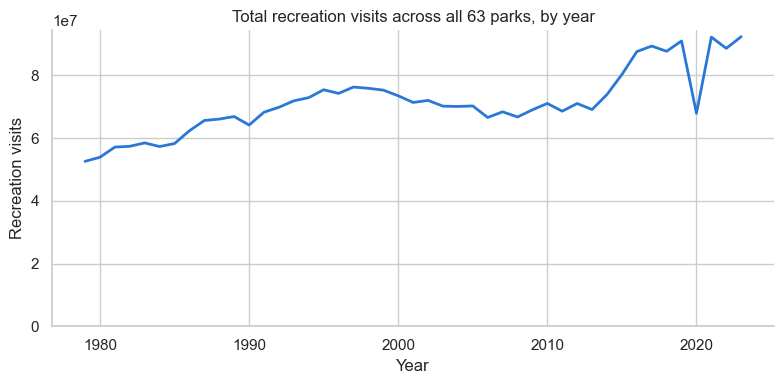

In [6]:
annual = df.groupby("Year")["RecreationVisits"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(annual.index, annual.values, color=BLUE, lw=2)
ax.set_title("Total recreation visits across all 63 parks, by year")
ax.set_xlabel("Year")
ax.set_ylabel("Recreation visits")
ax.set_ylim(bottom=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


National visits grew fairly steadily from 1979 to the early 2010s, dipped
sharply in 2020 (COVID-19 closures), and rebounded past prior levels by 2023.
This matches the well-known headline pattern, so it's a sanity check rather
than the interesting claim — but it confirms the data behaves as expected.

## Which parks dominate visitation?

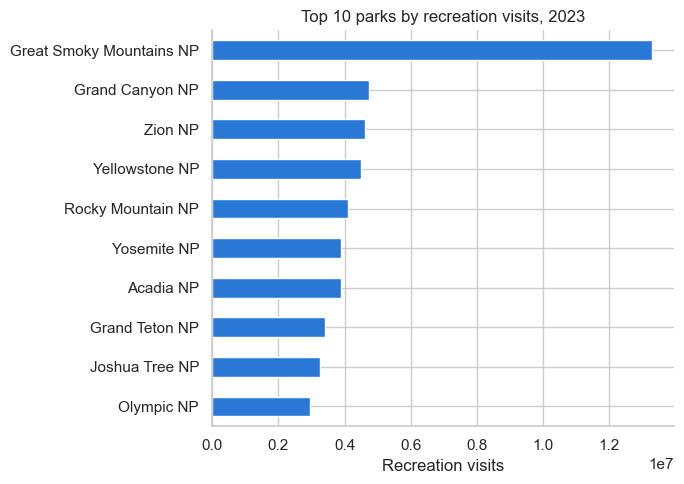

In [7]:
top_parks_2023 = (df[df.Year == 2023].groupby("ParkName")["RecreationVisits"]
                  .sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 5))
top_parks_2023.head(10).iloc[::-1].plot(kind="barh", ax=ax, color=BLUE)
ax.set_title("Top 10 parks by recreation visits, 2023")
ax.set_xlabel("Recreation visits")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [8]:
print("Share of 2023 visits held by top 10 parks:",
      round(top_parks_2023.head(10).sum() / top_parks_2023.sum(), 3))
print("Share of 2023 visits held by bottom 10 parks:",
      round(top_parks_2023.tail(10).sum() / top_parks_2023.sum(), 3))


Share of 2023 visits held by top 10 parks: 0.527
Share of 2023 visits held by bottom 10 parks: 0.005


Visitation is heavily concentrated: the top 10 parks capture a large share
of all recreation visits, while many remote parks (mostly in Alaska) draw a
small fraction. This concentration is a known, not-very-interesting fact on
its own (per the assignment prompt, "most visited park" claims are too shallow) —
but it's useful context for interpreting per-park patterns below, since a few
huge parks can dominate any *unweighted* national average.